<a href="https://colab.research.google.com/github/ARehman007-max/practic-projects/blob/main/Lungcaner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kagglehub -q

import kagglehub
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report

path = kagglehub.dataset_download("mohamedhanyyy/chest-ctscan-images")

Using Colab cache for faster access to the 'chest-ctscan-images' dataset.


In [2]:
train_dir = os.path.join(path, 'Data', 'train')
valid_dir = os.path.join(path, 'Data', 'valid')
test_dir  = os.path.join(path, 'Data', 'test')

img_size = (224, 224)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(train_dir, image_size=img_size, batch_size=batch_size, label_mode='int')
val_ds   = tf.keras.utils.image_dataset_from_directory(valid_dir, image_size=img_size, batch_size=batch_size, label_mode='int')
test_ds  = tf.keras.utils.image_dataset_from_directory(test_dir,  image_size=img_size, batch_size=batch_size, label_mode='int', shuffle=False)

class_names = train_ds.class_names
num_classes = len(class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

Found 613 files belonging to 4 classes.
Found 72 files belonging to 4 classes.
Found 315 files belonging to 4 classes.


In [3]:
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(256, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_ds, validation_data=val_ds, epochs=35)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/35
20/20 ━━━━━━━━━━━━━━━━━━━━ 102s 5s/step - accuracy: 0.3246 - loss: 1.3541 - val_accuracy: 0.4444 - val_loss: 1.2079
Epoch 2/35
20/20 ━━━━━━━━━━━━━━━━━━━━ 92s 5s/step - accuracy: 0.5595 - loss: 0.9967 - val_accuracy: 0.5694 - val_loss: 0.9240
Epoch 3/35
20/20 ━━━━━━━━━━━━━━━━━━━━ 89s 4s/step - accuracy: 0.7292 - loss: 0.7207 - val_accuracy: 0.6250 - val_loss: 0.7778
Epoch 4/35
20/20 ━━━━━━━━━━━━━━━━━━━━ 134s 4s/step - accuracy: 0.7781 - loss: 0.5767 - val_accuracy: 0.6944 - val_loss: 0.8372
Epoch 5/35
20/20 ━━━━━━━━━━━━━━━━━━━━ 92s 5s/step - accuracy: 0.8369 - loss: 0.4400 - val_accuracy: 0.7639 - val_loss: 0.6400
Epoch 6/35
20/20 ━━━━━━━━━━━━━━━━━━━━ 130s 4s/step - accuracy: 0.8874 - loss: 0.3137 - val_accuracy: 0.7083 - val_loss: 0.7556
Epoch 7/35
20/20 ━━━━━━━━━━━━━━━━━━━━ 80s 4s/step - accuracy: 0.8793 - loss: 0.3172 - val_accuracy: 0.7083 - val_loss: 0.9792
Epoch 8/35
20/20 ━━━━━━━━━━━━━━━━━━━━ 80s 4s/step - accuracy: 0.9152 - loss: 0.2407 - val_accuracy: 0.7083 - val_lo

In [4]:
y_pred = model.predict(test_ds)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.concatenate([y for x, y in test_ds], axis=0)

print(classification_report(y_true, y_pred_classes, target_names=class_names))

10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step
                                                  precision    recall  f1-score   support

      adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib       0.82      0.07      0.14       120
   large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa       0.41      0.53      0.46        51
                                          normal       0.36      0.96      0.53        54
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa       0.45      0.47      0.46        90

                                        accuracy                           0.41       315
                                       macro avg       0.51      0.51      0.40       315
                                    weighted avg       0.57      0.41      0.35       315



In [7]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

# Image path set to your uploaded file
image_path = "/content/healthylung.jfif"

try:
    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # Model prediction
    prediction = model.predict(img_array)
    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    print("Predicted:", predicted_class)
    print("Confidence:", round(confidence, 2), "%")
except Exception as e:
    print(f"Error: Make sure the file exists at {image_path}. Details: {e}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
Predicted: adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib
Confidence: 99.48 %


Using conv layer: conv2d_3


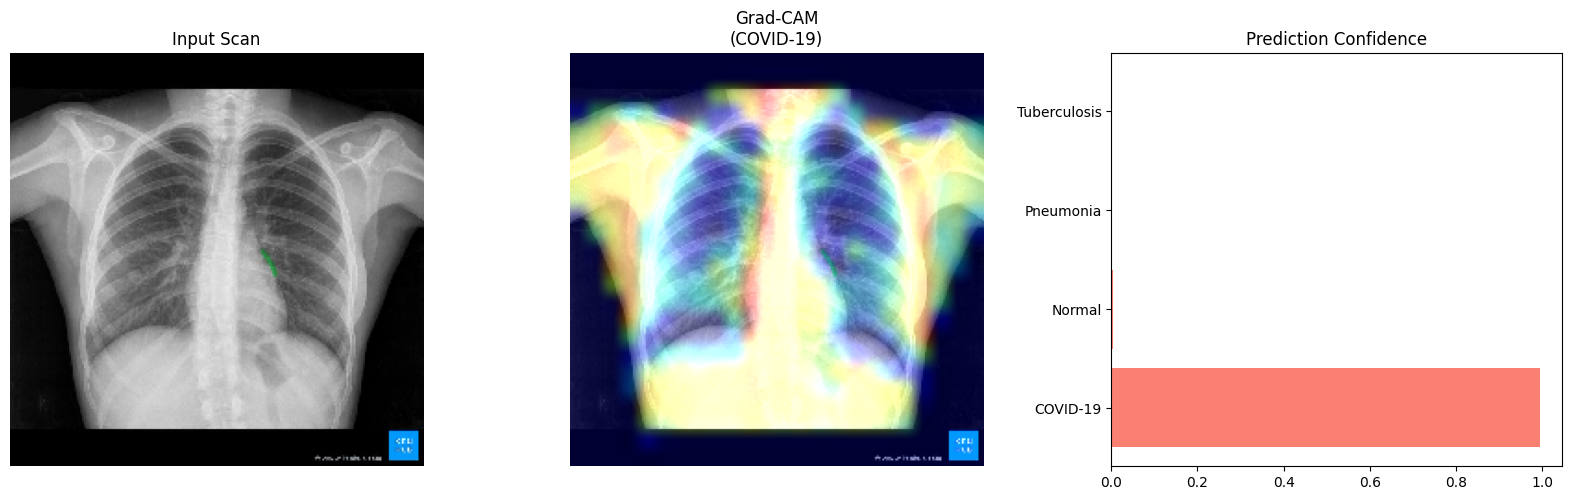

Result: COVID-19 (99.4800033569336%)


In [25]:
from tensorflow.keras.utils import load_img, img_to_array, array_to_img
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# ---- 4 classes (apne model ke mutabiq) ----
class_names = ['COVID-19', 'Normal', 'Pneumonia', 'Tuberculosis']

IMG_SIZE = (224, 224)


def build_grad_model(model, img_shape, last_conv_layer_name):
    inputs = tf.keras.Input(shape=img_shape)
    x = inputs
    conv_output = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.InputLayer):
            continue
        x = layer(x)
        if layer.name == last_conv_layer_name:
            conv_output = x
    if conv_output is None:
        raise ValueError(f"Conv layer '{last_conv_layer_name}' not found.")
    return tf.keras.models.Model(inputs=inputs, outputs=[conv_output, x])


def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = build_grad_model(model, img_array.shape[1:], last_conv_layer_name)
    with tf.GradientTape() as tape:
        conv_output, preds = grad_model(img_array, training=False)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = tf.math.divide_no_nan(heatmap, tf.reduce_max(heatmap))
    return heatmap.numpy()


image_path = "/content/healthylung.jfif"

try:
    img = load_img(image_path, target_size=IMG_SIZE)
    img_array = img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_batch, verbose=0)
    class_idx = int(np.argmax(preds[0]))
    num_classes = preds.shape[1]

    # ---- Safety: class_names aur preds length match karein ----
    if len(class_names) != num_classes:
        raise ValueError(
            f"class_names mein {len(class_names)} naam hain lekin model "
            f"{num_classes} classes predict kar raha hai. class_names update karein."
        )

    conv_layers = [l for l in model.layers if isinstance(l, tf.keras.layers.Conv2D)]
    last_conv_layer_name = conv_layers[-1].name
    print("Using conv layer:", last_conv_layer_name)

    heatmap = make_gradcam_heatmap(img_batch, model, last_conv_layer_name)

    heatmap = np.uint8(255 * heatmap)
    jet = plt.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = array_to_img(jet_heatmap).resize(IMG_SIZE)
    jet_heatmap = img_to_array(jet_heatmap)

    superimposed_img = jet_heatmap * 0.4 + img_array
    superimposed_img = tf.clip_by_value(superimposed_img, 0, 255)
    superimposed_img = array_to_img(superimposed_img)

    plt.figure(figsize=(16, 5))
    plt.subplot(1, 3, 1); plt.imshow(img); plt.title("Input Scan"); plt.axis("off")
    plt.subplot(1, 3, 2); plt.imshow(superimposed_img)
    plt.title(f"Grad-CAM\n({class_names[class_idx]})"); plt.axis("off")
    plt.subplot(1, 3, 3); plt.barh(class_names, preds[0], color='salmon')
    plt.title("Prediction Confidence")
    plt.tight_layout(); plt.show()

    print(f"Result: {class_names[class_idx]} ({round(np.max(preds)*100, 2)}%)")

except Exception as e:
    print(f"Error: {e}")

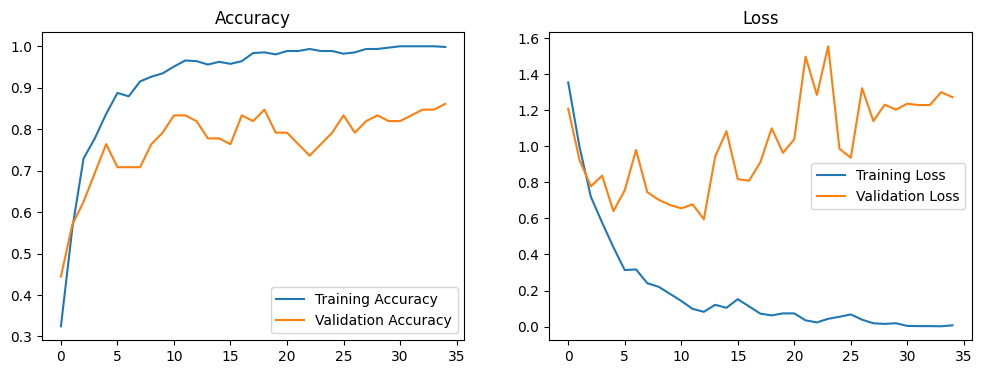

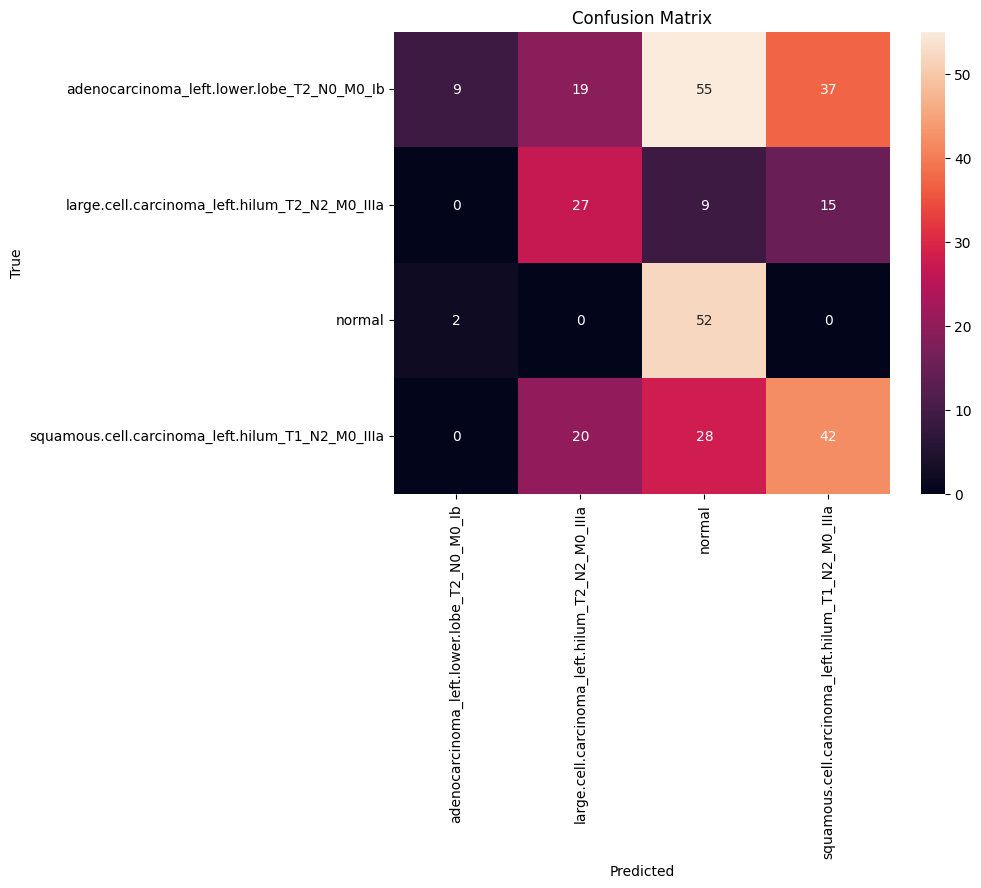

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss')
plt.show()

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()